In [52]:
# ============================================================
# Question 1: Monte Carlo Estimation for A_n and B_n
# ============================================================
#
# A_n = {x in R^n : ||x - (1/2)1||_2 <= 1/2}
# B_n = {x in R^n : ||x||_2 <= 1}
#
# A_n is a ball centered at (1/2,...,1/2) with radius 1/2.
# B_n is the unit ball centered at the origin.
#
# This code covers:
# 1.a: A_2 and B_2
# 1.b: A_3 and B_3
# 1.c: A_n and B_n, especially A_100 and B_100
# ============================================================


import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma, gammaln
from mpl_toolkits.mplot3d import Axes3D

In [53]:
# ============================================================
# Helper Function 1: Exact volume of an n-dimensional ball
# ============================================================
#
# Formula:
# Volume of n-ball with radius r:
#
# V_n(r) = pi^(n/2) / Gamma(n/2 + 1) * r^n
#
# For B_n: r = 1
# For A_n: r = 1/2
# ============================================================

def exact_n_ball_volume(n, r=1.0):
    """
    Compute the exact volume of an n-dimensional ball with radius r.

    Parameters
    ----------
    n : int
        Dimension.
    r : float
        Radius of the n-dimensional ball.

    Returns
    -------
    float
        Exact volume.
    """
    return (np.pi ** (n / 2)) / gamma(n / 2 + 1) * (r ** n)



# ============================================================
# Helper Function 2: Log-volume of an n-dimensional ball
# ============================================================
#
# In high dimensions, normal volume computation may underflow.
# So for n = 100, it is safer to compute log(volume).
#
# log V_n(r) = (n/2)log(pi) - log Gamma(n/2 + 1) + n log(r)
# ============================================================

def log_exact_n_ball_volume(n, r=1.0):
    """
    Compute the log-volume of an n-dimensional ball with radius r.

    This is more numerically stable for high dimensions.
    """
    return (n / 2) * np.log(np.pi) - gammaln(n / 2 + 1) + n * np.log(r)



# ============================================================
# Helper Function 3: Monte Carlo estimation for A_n
# ============================================================
#
# A_n is inside the unit box [0,1]^n.
#
# Sampling region:
# X_i ~ Uniform([0,1]^n)
#
# A point is inside A_n if:
# ||X_i - (1/2,...,1/2)||_2 <= 1/2
#
# Since volume of [0,1]^n is 1, the estimator is:
#
# Vol(A_n) ≈ (# inside A_n) / N
# ============================================================

def monte_carlo_A(n, N, seed=42):
    """
    Estimate volume of A_n using naive Monte Carlo rejection sampling.

    Parameters
    ----------
    n : int
        Dimension.
    N : int
        Number of random samples.
    seed : int
        Random seed for reproducibility.

    Returns
    -------
    estimate : float
        Monte Carlo volume estimate.
    inside_count : int
        Number of points inside A_n.
    acceptance_rate : float
        Proportion of sampled points inside A_n.
    """
    np.random.seed(seed)

    # Generate N random points uniformly from [0,1]^n
    X = np.random.uniform(0, 1, size=(N, n))

    # Center of A_n is (1/2,...,1/2)
    center = np.full(n, 0.5)

    # Compute Euclidean distance from each point to the center
    distances = np.linalg.norm(X - center, axis=1)

    # Check whether each point lies inside A_n
    inside = distances <= 0.5

    # Count accepted points
    inside_count = np.sum(inside)

    # Since box volume is 1, estimate equals acceptance rate
    acceptance_rate = inside_count / N
    estimate = acceptance_rate

    return estimate, inside_count, acceptance_rate



# ============================================================
# Helper Function 4: Monte Carlo estimation for B_n
# ============================================================
#
# B_n is inside the box [-1,1]^n.
#
# Sampling region:
# X_i ~ Uniform([-1,1]^n)
#
# A point is inside B_n if:
# ||X_i||_2 <= 1
#
# Volume of [-1,1]^n is 2^n.
#
# Estimator:
#
# Vol(B_n) ≈ 2^n * (# inside B_n) / N
# ============================================================

def monte_carlo_B(n, N, seed=42):
    """
    Estimate volume of B_n using naive Monte Carlo rejection sampling.

    Parameters
    ----------
    n : int
        Dimension.
    N : int
        Number of random samples.
    seed : int
        Random seed for reproducibility.

    Returns
    -------
    estimate : float
        Monte Carlo volume estimate.
    inside_count : int
        Number of points inside B_n.
    acceptance_rate : float
        Proportion of sampled points inside B_n.
    """
    np.random.seed(seed)

    # Generate N random points uniformly from [-1,1]^n
    X = np.random.uniform(-1, 1, size=(N, n))

    # Compute Euclidean norm of each point
    distances = np.linalg.norm(X, axis=1)

    # Check whether each point lies inside B_n
    inside = distances <= 1

    # Count accepted points
    inside_count = np.sum(inside)

    # Volume of bounding box [-1,1]^n
    box_volume = 2 ** n

    # Monte Carlo estimate
    acceptance_rate = inside_count / N
    estimate = box_volume * acceptance_rate

    return estimate, inside_count, acceptance_rate



# ============================================================
# Helper Function 5: Error metrics
# ============================================================

def compute_errors(estimate, exact):
    """
    Compute absolute error and relative error.

    Absolute Error = |estimate - exact|
    Relative Error = |estimate - exact| / exact
    """
    absolute_error = abs(estimate - exact)
    relative_error = absolute_error / exact if exact != 0 else np.nan

    return absolute_error, relative_error

# Question 1a:

In [54]:
# ============================================================
# Part 1.a: Exact areas of A_2 and B_2
# ============================================================

exact_A2 = exact_n_ball_volume(n=2, r=0.5)
exact_B2 = exact_n_ball_volume(n=2, r=1.0)

print("Exact Area of A_2:", exact_A2)
print("Exact Area of B_2:", exact_B2)

Exact Area of A_2: 0.7853981633974483
Exact Area of B_2: 3.141592653589793


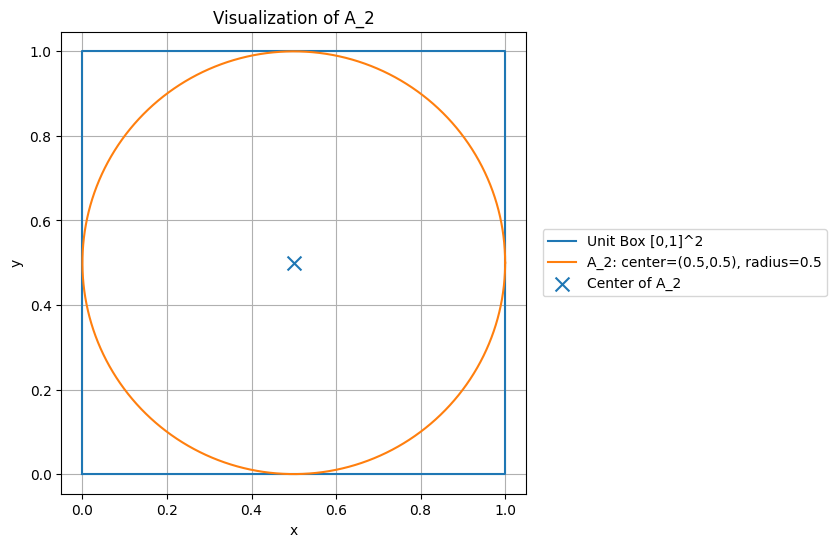

In [55]:
# ============================================================
# Part 1.a: Visualize A_2
# ============================================================
#
# A_2 is a circle centered at (0.5, 0.5) with radius 0.5.
# It is inscribed inside the unit square [0,1]^2.
# ============================================================

theta = np.linspace(0, 2*np.pi, 400)

# Circle boundary for A_2
x_A2 = 0.5 + 0.5 * np.cos(theta)
y_A2 = 0.5 + 0.5 * np.sin(theta)

plt.figure(figsize=(6, 6))

# Draw unit square
plt.plot([0, 1, 1, 0, 0], [0, 0, 1, 1, 0], label="Unit Box [0,1]^2")

# Draw A_2 circle
plt.plot(x_A2, y_A2, label="A_2: center=(0.5,0.5), radius=0.5")

# Draw center
plt.scatter([0.5], [0.5], marker="x", s=100, label="Center of A_2")

plt.title("Visualization of A_2")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.grid(True)

# Move legend outside so it does not cover the center
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))

plt.show()

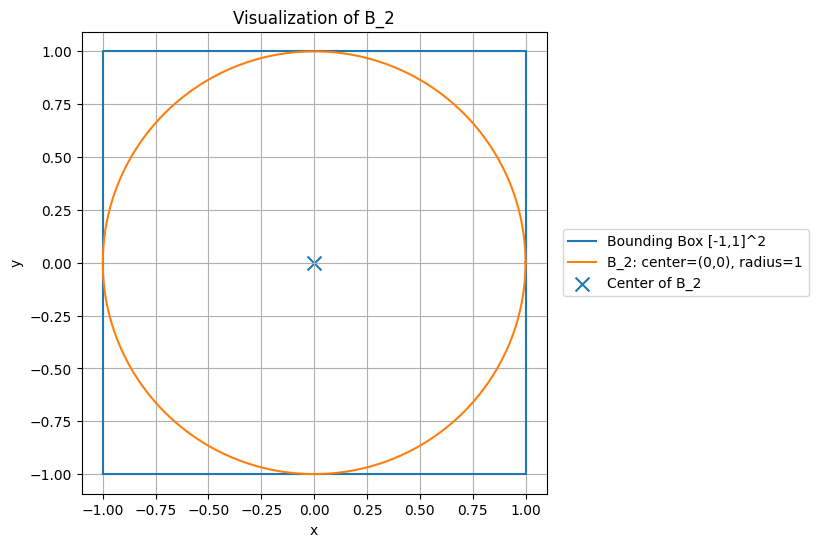

In [56]:
# ============================================================
# Part 1.a: Visualize B_2
# ============================================================
#
# B_2 is a unit circle centered at (0,0) with radius 1.
# It is inside the square [-1,1]^2.
# ============================================================

theta = np.linspace(0, 2*np.pi, 400)

# Circle boundary for B_2
x_B2 = np.cos(theta)
y_B2 = np.sin(theta)

plt.figure(figsize=(6, 6))

# Draw bounding square [-1,1]^2
plt.plot([-1, 1, 1, -1, -1], [-1, -1, 1, 1, -1], label="Bounding Box [-1,1]^2")

# Draw B_2 circle
plt.plot(x_B2, y_B2, label="B_2: center=(0,0), radius=1")

# Draw center
plt.scatter([0], [0], marker="x", s=100, label="Center of B_2")

plt.title("Visualization of B_2")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.grid(True)

# Move legend outside
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))

plt.show()

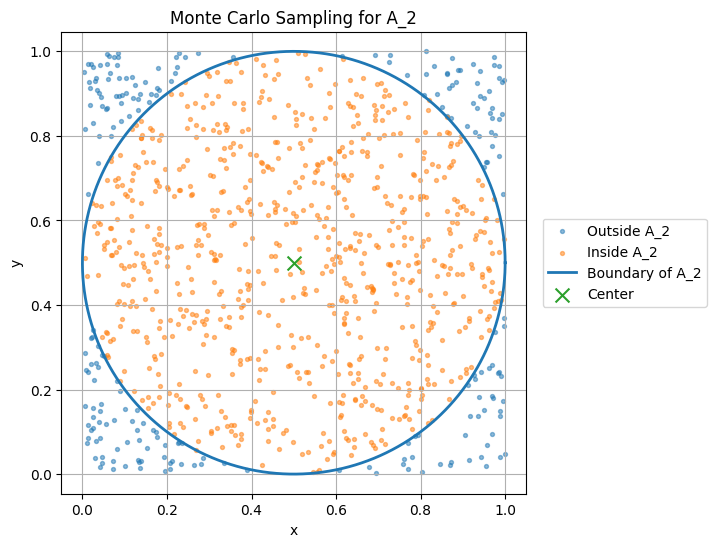

In [57]:
# ============================================================
# Part 1.a: Monte Carlo Visualization for A_2
# ============================================================
#
# Red points: inside A_2
# Blue points: outside A_2 but inside [0,1]^2
# ============================================================

# N = int(input("Enter number of samples for A_2 Monte Carlo visualization: "))

N = 1000

np.random.seed(42)

# Sample points from [0,1]^2
X = np.random.uniform(0, 1, size=(N, 2))

# Check whether each point is inside A_2
center_A2 = np.array([0.5, 0.5])
distances = np.linalg.norm(X - center_A2, axis=1)
inside = distances <= 0.5

# Separate inside and outside points
inside_points = X[inside]
outside_points = X[~inside]

plt.figure(figsize=(6, 6))

# Plot outside points
plt.scatter(outside_points[:, 0], outside_points[:, 1], s=8, alpha=0.5, label="Outside A_2")

# Plot inside points
plt.scatter(inside_points[:, 0], inside_points[:, 1], s=8, alpha=0.5, label="Inside A_2")

# Plot boundary of A_2
plt.plot(x_A2, y_A2, linewidth=2, label="Boundary of A_2")

# Plot center
plt.scatter([0.5], [0.5], marker="x", s=100, label="Center")

plt.title("Monte Carlo Sampling for A_2")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.grid(True)
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))

plt.show()

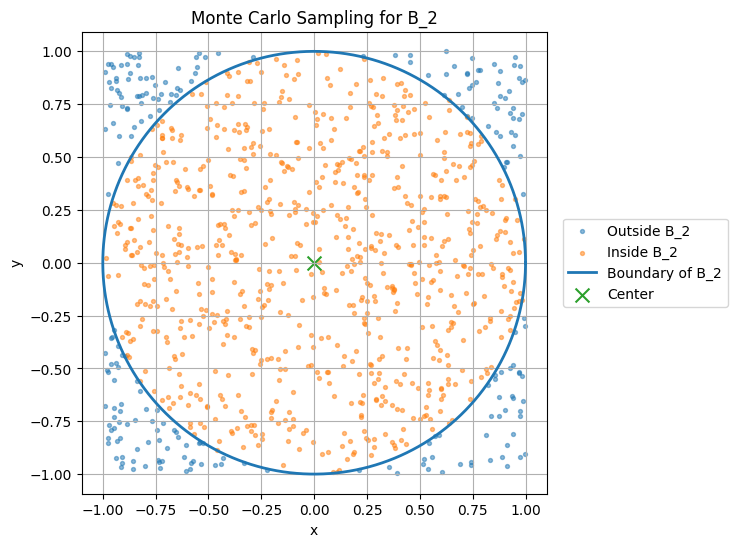

In [58]:
# ============================================================
# Part 1.a: Monte Carlo Visualization for B_2
# ============================================================
#
# Red points: inside B_2
# Blue points: outside B_2 but inside [-1,1]^2
# ============================================================

# N = int(input("Enter number of samples for B_2 Monte Carlo visualization: "))

N = 1000

np.random.seed(42)

# Sample points from [-1,1]^2
X = np.random.uniform(-1, 1, size=(N, 2))

# Check whether each point is inside B_2
distances = np.linalg.norm(X, axis=1)
inside = distances <= 1

# Separate inside and outside points
inside_points = X[inside]
outside_points = X[~inside]

plt.figure(figsize=(6, 6))

# Plot outside points
plt.scatter(outside_points[:, 0], outside_points[:, 1], s=8, alpha=0.5, label="Outside B_2")

# Plot inside points
plt.scatter(inside_points[:, 0], inside_points[:, 1], s=8, alpha=0.5, label="Inside B_2")

# Plot boundary
plt.plot(x_B2, y_B2, linewidth=2, label="Boundary of B_2")

# Plot center
plt.scatter([0], [0], marker="x", s=100, label="Center")

plt.title("Monte Carlo Sampling for B_2")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.grid(True)
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))

plt.show()

In [59]:
# ============================================================
# Part 1.a: Monte Carlo estimates for A_2 and B_2
# ============================================================

# N = int(input("Enter number of Monte Carlo samples for 1.a: "))

N = 1000

# Estimate A_2
estimate_A2, inside_A2, acc_A2 = monte_carlo_A(n=2, N=N, seed=42)
abs_err_A2, rel_err_A2 = compute_errors(estimate_A2, exact_A2)

# Estimate B_2
estimate_B2, inside_B2, acc_B2 = monte_carlo_B(n=2, N=N, seed=42)
abs_err_B2, rel_err_B2 = compute_errors(estimate_B2, exact_B2)

print("========== Part 1.a Results ==========")

print("\nA_2:")
print("Exact Area:", exact_A2)
print("Monte Carlo Estimate:", estimate_A2)
print("Number of Points Inside:", inside_A2)
print("Acceptance Rate:", acc_A2)
print("Absolute Error:", abs_err_A2)
print("Relative Error:", rel_err_A2)

print("\nB_2:")
print("Exact Area:", exact_B2)
print("Monte Carlo Estimate:", estimate_B2)
print("Number of Points Inside:", inside_B2)
print("Acceptance Rate:", acc_B2)
print("Absolute Error:", abs_err_B2)
print("Relative Error:", rel_err_B2)

========== Part 1.a Results ==========

A_2:
Exact Area: 0.7853981633974483
Monte Carlo Estimate: 0.776
Number of Points Inside: 776
Acceptance Rate: 0.776
Absolute Error: 0.009398163397448256
Relative Error: 0.011966113285513688

B_2:
Exact Area: 3.141592653589793
Monte Carlo Estimate: 3.104
Number of Points Inside: 776
Acceptance Rate: 0.776
Absolute Error: 0.037592653589793024
Relative Error: 0.011966113285513688


# Question 1b

In [60]:
# ============================================================
# Part 1.b: Exact volumes of A_3 and B_3
# ============================================================

exact_A3 = exact_n_ball_volume(n=3, r=0.5)
exact_B3 = exact_n_ball_volume(n=3, r=1.0)

print("Exact Volume of A_3:", exact_A3)
print("Exact Volume of B_3:", exact_B3)

Exact Volume of A_3: 0.5235987755982989
Exact Volume of B_3: 4.188790204786391


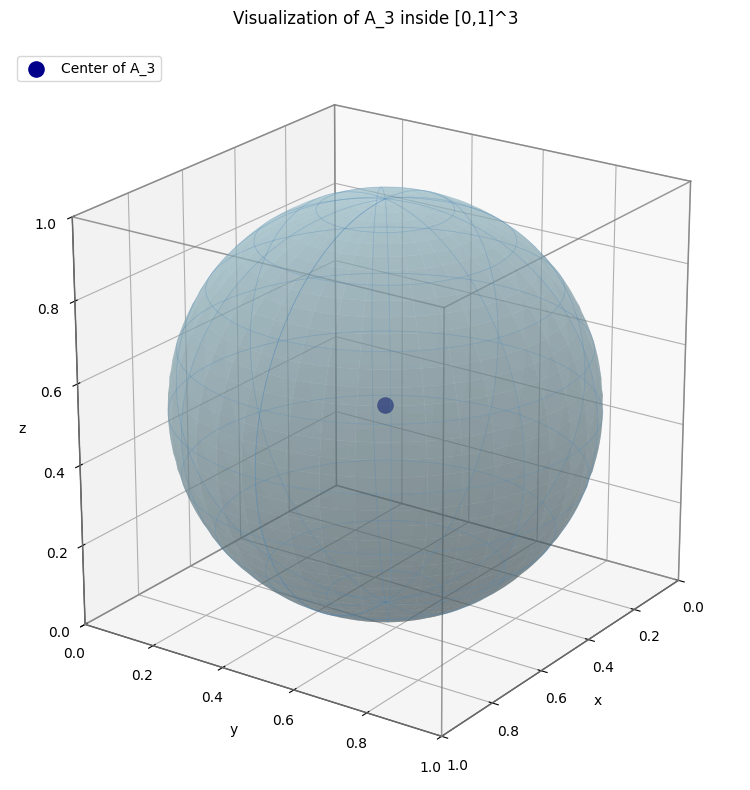

In [61]:
# ============================================================
# Part 1.b: Visualize A_3
# ============================================================
#
# A_3 is a sphere centered at (0.5,0.5,0.5)
# with radius 0.5, inside the cube [0,1]^3.
# =========================================================== 


import numpy as np

import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D

def draw_cube_edges(ax, lower, upper):

    """

    Draw the edges of a cube from lower bound to upper bound.

    """

    x0, y0, z0 = lower

    x1, y1, z1 = upper

    corners = np.array([

        [x0, y0, z0],

        [x1, y0, z0],

        [x1, y1, z0],

        [x0, y1, z0],

        [x0, y0, z1],

        [x1, y0, z1],

        [x1, y1, z1],

        [x0, y1, z1]

    ])

    edges = [

        (0, 1), (1, 2), (2, 3), (3, 0),

        (4, 5), (5, 6), (6, 7), (7, 4),

        (0, 4), (1, 5), (2, 6), (3, 7)

    ]

    for i, j in edges:

        ax.plot(

            [corners[i, 0], corners[j, 0]],

            [corners[i, 1], corners[j, 1]],

            [corners[i, 2], corners[j, 2]],

            color="gray",

            linewidth=1.1,

            alpha=0.8

        )

center = np.array([0.5, 0.5, 0.5])

radius = 0.5

u = np.linspace(0, 2 * np.pi, 80)

v = np.linspace(0, np.pi, 80)

x = center[0] + radius * np.outer(np.cos(u), np.sin(v))

y = center[1] + radius * np.outer(np.sin(u), np.sin(v))

z = center[2] + radius * np.outer(np.ones_like(u), np.cos(v))

fig = plt.figure(figsize=(9, 8))

ax = fig.add_subplot(111, projection="3d")

draw_cube_edges(ax, lower=(0, 0, 0), upper=(1, 1, 1))

ax.plot_surface(

    x, y, z,

    color="lightblue",

    alpha=0.45,

    linewidth=0,

    antialiased=True

)

ax.plot_wireframe(

    x, y, z,

    color="steelblue",

    rstride=8,

    cstride=8,

    linewidth=0.5,

    alpha=0.35

)

ax.scatter(

    [center[0]], [center[1]], [center[2]],

    color="darkblue",

    s=120,

    marker="o",

    label="Center of A_3"

)

ax.set_title("Visualization of A_3 inside [0,1]^3", pad=18)

ax.set_xlabel("x")

ax.set_ylabel("y")

ax.set_zlabel("z")

ax.set_xlim(0, 1)

ax.set_ylim(0, 1)

ax.set_zlim(0, 1)

ax.set_box_aspect([1, 1, 1])

ax.view_init(elev=22, azim=35)

ax.legend(loc="upper left")

plt.tight_layout()

plt.show()

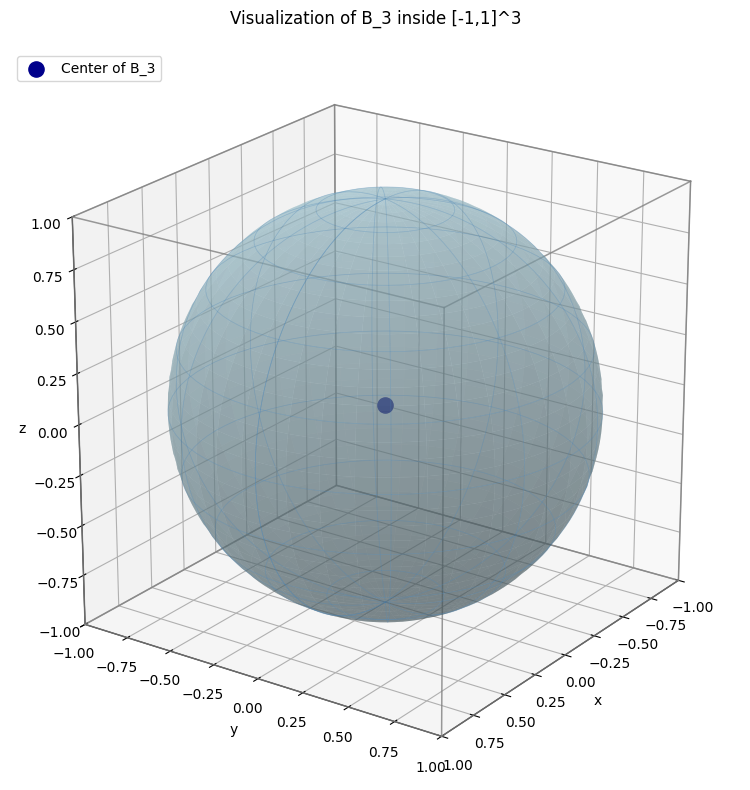

In [62]:
# ============================================================
# Part 1.b: Visualize B_3
# ============================================================
#
# B_3 is the unit sphere centered at (0,0,0)
# with radius 1, inside the cube [-1,1]^3.
# ============================================================

center = np.array([0, 0, 0])

radius = 1.0

u = np.linspace(0, 2 * np.pi, 80)

v = np.linspace(0, np.pi, 80)

x = center[0] + radius * np.outer(np.cos(u), np.sin(v))

y = center[1] + radius * np.outer(np.sin(u), np.sin(v))

z = center[2] + radius * np.outer(np.ones_like(u), np.cos(v))

fig = plt.figure(figsize=(9, 8))

ax = fig.add_subplot(111, projection="3d")

draw_cube_edges(ax, lower=(-1, -1, -1), upper=(1, 1, 1))

ax.plot_surface(

    x, y, z,

    color="lightblue",

    alpha=0.45,

    linewidth=0,

    antialiased=True

)

ax.plot_wireframe(

    x, y, z,

    color="steelblue",

    rstride=8,

    cstride=8,

    linewidth=0.5,

    alpha=0.35

)

ax.scatter(

    [center[0]], [center[1]], [center[2]],

    color="darkblue",

    s=120,

    marker="o",

    label="Center of B_3"

)

ax.set_title("Visualization of B_3 inside [-1,1]^3", pad=18)

ax.set_xlabel("x")

ax.set_ylabel("y")

ax.set_zlabel("z")

ax.set_xlim(-1, 1)

ax.set_ylim(-1, 1)

ax.set_zlim(-1, 1)

ax.set_box_aspect([1, 1, 1])

ax.view_init(elev=22, azim=35)

ax.legend(loc="upper left")

plt.tight_layout()

plt.show()

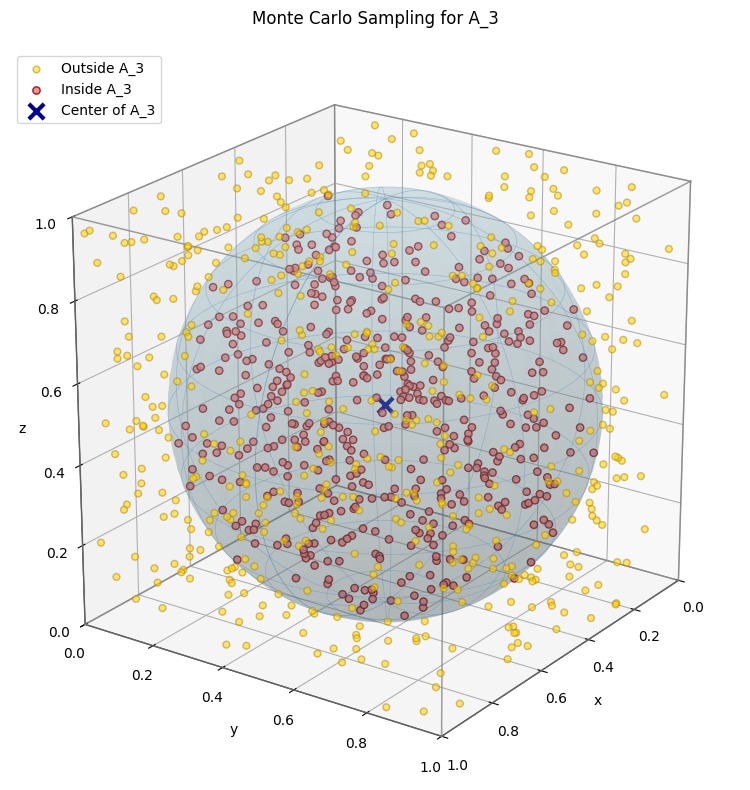

In [63]:
# ============================================================
# Part 1.b: Monte Carlo Visualization for A_3
# ============================================================
#
# Red points: inside A_3
# Blue points: outside A_3 but inside [0,1]^3
# ============================================================

# N = int(input("Enter number of samples for A_3 Monte Carlo visualization: "))

import numpy as np

import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D

def draw_cube_edges(ax, lower, upper):

    """

    Draw the edges of a cube from lower bound to upper bound.

    """

    x0, y0, z0 = lower

    x1, y1, z1 = upper

    corners = np.array([

        [x0, y0, z0],

        [x1, y0, z0],

        [x1, y1, z0],

        [x0, y1, z0],

        [x0, y0, z1],

        [x1, y0, z1],

        [x1, y1, z1],

        [x0, y1, z1]

    ])

    edges = [

        (0, 1), (1, 2), (2, 3), (3, 0),

        (4, 5), (5, 6), (6, 7), (7, 4),

        (0, 4), (1, 5), (2, 6), (3, 7)

    ]

    for i, j in edges:

        ax.plot(

            [corners[i, 0], corners[j, 0]],

            [corners[i, 1], corners[j, 1]],

            [corners[i, 2], corners[j, 2]],

            color="gray",

            linewidth=1.1,

            alpha=0.75

        )

N = 1000

np.random.seed(42)

# Sample points from [0,1]^3

X = np.random.uniform(0, 1, size=(N, 3))

# Define A_3

center_A3 = np.array([0.5, 0.5, 0.5])

radius_A3 = 0.5

# Check whether each point is inside A_3

distances = np.linalg.norm(X - center_A3, axis=1)

inside = distances <= radius_A3

inside_points = X[inside]

outside_points = X[~inside]

# Create sphere surface for A_3

u = np.linspace(0, 2 * np.pi, 80)

v = np.linspace(0, np.pi, 80)

sphere_x = center_A3[0] + radius_A3 * np.outer(np.cos(u), np.sin(v))

sphere_y = center_A3[1] + radius_A3 * np.outer(np.sin(u), np.sin(v))

sphere_z = center_A3[2] + radius_A3 * np.outer(np.ones_like(u), np.cos(v))

fig = plt.figure(figsize=(9, 8))

ax = fig.add_subplot(111, projection="3d")

# Draw bounding cube [0,1]^3

draw_cube_edges(ax, lower=(0, 0, 0), upper=(1, 1, 1))

# Plot outside points first so inside points remain more visible

ax.scatter(

    outside_points[:, 0],

    outside_points[:, 1],

    outside_points[:, 2],

    color="gold",

    edgecolor="darkgoldenrod",

    s=24,

    alpha=0.55,

    label="Outside A_3"

)

# Plot inside points

ax.scatter(

    inside_points[:, 0],

    inside_points[:, 1],

    inside_points[:, 2],

    color="lightcoral",

    edgecolor="darkred",

    s=28,

    alpha=0.85,

    label="Inside A_3"

)

# Plot transparent sphere surface

ax.plot_surface(

    sphere_x,

    sphere_y,

    sphere_z,

    color="lightblue",

    alpha=0.22,

    linewidth=0,

    antialiased=True

)

# Plot sphere wireframe

ax.plot_wireframe(

    sphere_x,

    sphere_y,

    sphere_z,

    color="steelblue",

    rstride=8,

    cstride=8,

    linewidth=0.5,

    alpha=0.35

)

# Plot center

ax.scatter(

    [center_A3[0]],

    [center_A3[1]],

    [center_A3[2]],

    color="darkblue",

    s=120,

    marker="x",

    linewidths=3,

    label="Center of A_3"

)

# Titles and labels

ax.set_title("Monte Carlo Sampling for A_3", pad=18)

ax.set_xlabel("x")

ax.set_ylabel("y")

ax.set_zlabel("z")

# Axis limits

ax.set_xlim(0, 1)

ax.set_ylim(0, 1)

ax.set_zlim(0, 1)

# Equal aspect ratio

ax.set_box_aspect([1, 1, 1])

# Better viewing angle

ax.view_init(elev=22, azim=35)

# Legend

ax.legend(loc="upper left")

plt.tight_layout()

plt.show()

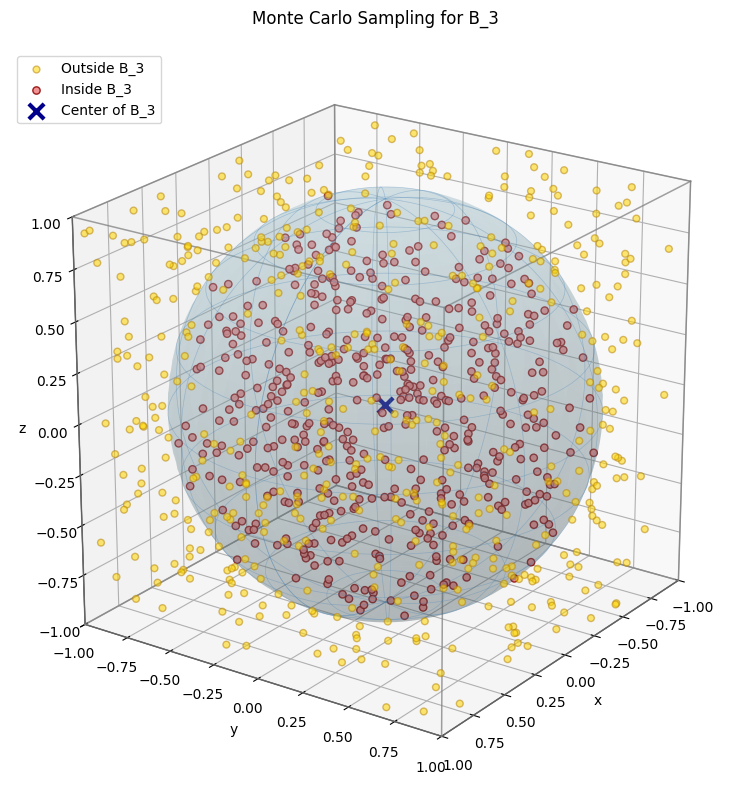

In [64]:
# ============================================================
# Part 1.b: Monte Carlo Visualization for B_3
# ============================================================
#
# Red points: inside B_3
# Blue points: outside B_3 but inside [-1,1]^3
# ============================================================

# N = int(input("Enter number of samples for B_3 Monte Carlo visualization: "))

def draw_cube_edges(ax, lower, upper):

    """

    Draw the edges of a cube from lower bound to upper bound.

    """

    x0, y0, z0 = lower

    x1, y1, z1 = upper

    corners = np.array([

        [x0, y0, z0],

        [x1, y0, z0],

        [x1, y1, z0],

        [x0, y1, z0],

        [x0, y0, z1],

        [x1, y0, z1],

        [x1, y1, z1],

        [x0, y1, z1]

    ])

    edges = [

        (0, 1), (1, 2), (2, 3), (3, 0),

        (4, 5), (5, 6), (6, 7), (7, 4),

        (0, 4), (1, 5), (2, 6), (3, 7)

    ]

    for i, j in edges:

        ax.plot(

            [corners[i, 0], corners[j, 0]],

            [corners[i, 1], corners[j, 1]],

            [corners[i, 2], corners[j, 2]],

            color="gray",

            linewidth=1.1,

            alpha=0.75

        )

N = 1000

np.random.seed(42)

# Sample points from [-1,1]^3

X = np.random.uniform(-1, 1, size=(N, 3))

# Define B_3

center_B3 = np.array([0.0, 0.0, 0.0])

radius_B3 = 1.0

# Check whether each point is inside B_3

distances = np.linalg.norm(X - center_B3, axis=1)

inside = distances <= radius_B3

inside_points = X[inside]

outside_points = X[~inside]

# Create sphere surface for B_3

u = np.linspace(0, 2 * np.pi, 80)

v = np.linspace(0, np.pi, 80)

sphere_x = center_B3[0] + radius_B3 * np.outer(np.cos(u), np.sin(v))

sphere_y = center_B3[1] + radius_B3 * np.outer(np.sin(u), np.sin(v))

sphere_z = center_B3[2] + radius_B3 * np.outer(np.ones_like(u), np.cos(v))

fig = plt.figure(figsize=(9, 8))

ax = fig.add_subplot(111, projection="3d")

# Draw bounding cube [-1,1]^3

draw_cube_edges(ax, lower=(-1, -1, -1), upper=(1, 1, 1))

# Plot outside points first

ax.scatter(

    outside_points[:, 0],

    outside_points[:, 1],

    outside_points[:, 2],

    color="gold",

    edgecolor="darkgoldenrod",

    s=24,

    alpha=0.55,

    label="Outside B_3"

)

# Plot inside points

ax.scatter(

    inside_points[:, 0],

    inside_points[:, 1],

    inside_points[:, 2],

    color="lightcoral",

    edgecolor="darkred",

    s=28,

    alpha=0.85,

    label="Inside B_3"

)

# Plot transparent sphere surface

ax.plot_surface(

    sphere_x,

    sphere_y,

    sphere_z,

    color="lightblue",

    alpha=0.22,

    linewidth=0,

    antialiased=True

)

# Plot sphere wireframe

ax.plot_wireframe(

    sphere_x,

    sphere_y,

    sphere_z,

    color="steelblue",

    rstride=8,

    cstride=8,

    linewidth=0.5,

    alpha=0.35

)

# Plot center

ax.scatter(

    [center_B3[0]],

    [center_B3[1]],

    [center_B3[2]],

    color="darkblue",

    s=120,

    marker="x",

    linewidths=3,

    label="Center of B_3"

)

# Titles and labels

ax.set_title("Monte Carlo Sampling for B_3", pad=18)

ax.set_xlabel("x")

ax.set_ylabel("y")

ax.set_zlabel("z")

# Axis limits

ax.set_xlim(-1, 1)

ax.set_ylim(-1, 1)

ax.set_zlim(-1, 1)

# Equal aspect ratio

ax.set_box_aspect([1, 1, 1])

# Better viewing angle

ax.view_init(elev=22, azim=35)

# Legend

ax.legend(loc="upper left")

plt.tight_layout()

plt.show()

In [65]:
# ============================================================
# Part 1.b: Monte Carlo estimates for A_3 and B_3
# ============================================================

# N = int(input("Enter number of Monte Carlo samples for 1.b: "))

N = 1000

# Estimate A_3
estimate_A3, inside_A3, acc_A3 = monte_carlo_A(n=3, N=N, seed=42)
abs_err_A3, rel_err_A3 = compute_errors(estimate_A3, exact_A3)

# Estimate B_3
estimate_B3, inside_B3, acc_B3 = monte_carlo_B(n=3, N=N, seed=42)
abs_err_B3, rel_err_B3 = compute_errors(estimate_B3, exact_B3)

print("========== Part 1.b Results ==========")

print("\nA_3:")
print("Exact Volume:", exact_A3)
print("Monte Carlo Estimate:", estimate_A3)
print("Number of Points Inside:", inside_A3)
print("Acceptance Rate:", acc_A3)
print("Absolute Error:", abs_err_A3)
print("Relative Error:", rel_err_A3)

print("\nB_3:")
print("Exact Volume:", exact_B3)
print("Monte Carlo Estimate:", estimate_B3)
print("Number of Points Inside:", inside_B3)
print("Acceptance Rate:", acc_B3)
print("Absolute Error:", abs_err_B3)
print("Relative Error:", rel_err_B3)

========== Part 1.b Results ==========

A_3:
Exact Volume: 0.5235987755982989
Monte Carlo Estimate: 0.499
Number of Points Inside: 499
Acceptance Rate: 0.499
Absolute Error: 0.024598775598298928
Relative Error: 0.046980200765730826

B_3:
Exact Volume: 4.188790204786391
Monte Carlo Estimate: 3.992
Number of Points Inside: 499
Acceptance Rate: 0.499
Absolute Error: 0.19679020478639142
Relative Error: 0.046980200765730826


# Question 1c

In [66]:
# ============================================================
# Part 1.c: Exact volume formulas for A_n and B_n
# ============================================================

def exact_A_volume(n):
    """
    Exact volume of A_n.

    A_n has radius 1/2.
    """
    return exact_n_ball_volume(n=n, r=0.5)


def exact_B_volume(n):
    """
    Exact volume of B_n.

    B_n has radius 1.
    """
    return exact_n_ball_volume(n=n, r=1.0)


def log_exact_A_volume(n):
    """
    Log exact volume of A_n.
    Useful for high dimensions.
    """
    return log_exact_n_ball_volume(n=n, r=0.5)


def log_exact_B_volume(n):
    """
    Log exact volume of B_n.
    Useful for high dimensions.
    """
    return log_exact_n_ball_volume(n=n, r=1.0)

In [67]:
# ============================================================
# Part 1.c: Exact volumes for A_100 and B_100
# ============================================================

n = 100

exact_A100 = exact_A_volume(n)
exact_B100 = exact_B_volume(n)

log_exact_A100 = log_exact_A_volume(n)
log_exact_B100 = log_exact_B_volume(n)

print("========== Exact Volumes for n = 100 ==========")

print("\nB_100:")
print("Exact Volume:", exact_B100)
print("Log Exact Volume:", log_exact_B100)

print("\nA_100:")
print("Exact Volume:", exact_A100)
print("Log Exact Volume:", log_exact_A100)

========== Exact Volumes for n = 100 ==========

B_100:
Exact Volume: 2.368202101882829e-40
Log Exact Volume: -91.24127265930301

A_100:
Exact Volume: 1.8681820538375912e-70
Log Exact Volume: -160.55599071529753


In [68]:
# ============================================================
# Part 1.c: Naive Monte Carlo estimates for A_100 and B_100
# ============================================================
#
# Warning:
# In high dimensions, this method becomes extremely inefficient.
# Most sampled points from the bounding box will fall outside the ball.
#
# This is the curse of dimensionality.
# ============================================================

# N = int(input("Enter number of Monte Carlo samples for A_100 and B_100: "))

N = 1000 

# Estimate A_100
estimate_A100, inside_A100, acc_A100 = monte_carlo_A(n=100, N=N, seed=42)
abs_err_A100, rel_err_A100 = compute_errors(estimate_A100, exact_A100)

# Estimate B_100
estimate_B100, inside_B100, acc_B100 = monte_carlo_B(n=100, N=N, seed=42)
abs_err_B100, rel_err_B100 = compute_errors(estimate_B100, exact_B100)

print("========== Part 1.c Monte Carlo Results ==========")

print("\nA_100:")
print("Exact Volume:", exact_A100)
print("Monte Carlo Estimate:", estimate_A100)
print("Number of Points Inside:", inside_A100)
print("Acceptance Rate:", acc_A100)
print("Absolute Error:", abs_err_A100)
print("Relative Error:", rel_err_A100)

print("\nB_100:")
print("Exact Volume:", exact_B100)
print("Monte Carlo Estimate:", estimate_B100)
print("Number of Points Inside:", inside_B100)
print("Acceptance Rate:", acc_B100)
print("Absolute Error:", abs_err_B100)
print("Relative Error:", rel_err_B100)

========== Part 1.c Monte Carlo Results ==========

A_100:
Exact Volume: 1.8681820538375912e-70
Monte Carlo Estimate: 0.0
Number of Points Inside: 0
Acceptance Rate: 0.0
Absolute Error: 1.8681820538375912e-70
Relative Error: 1.0

B_100:
Exact Volume: 2.368202101882829e-40
Monte Carlo Estimate: 0.0
Number of Points Inside: 0
Acceptance Rate: 0.0
Absolute Error: 2.368202101882829e-40
Relative Error: 1.0


# Explorations

In [69]:
# ============================================================
# Compare Monte Carlo performance from dimension 2 to 20
# ============================================================

N = 100000

dimensions = list(range(2, 21))

results = []

for n in dimensions:
    exact_A = exact_A_volume(n)
    exact_B = exact_B_volume(n)

    estimate_A, inside_A, acc_A = monte_carlo_A(n=n, N=N, seed=42)
    estimate_B, inside_B, acc_B = monte_carlo_B(n=n, N=N, seed=42)

    abs_err_A, rel_err_A = compute_errors(estimate_A, exact_A)
    abs_err_B, rel_err_B = compute_errors(estimate_B, exact_B)

    results.append([
        n,
        exact_A,
        estimate_A,
        acc_A,
        rel_err_A,
        exact_B,
        estimate_B,
        acc_B,
        rel_err_B
    ])


# Print results in a clean format
print("Dimension | Exact A_n | MC A_n | Acc A_n | Rel Err A_n | Exact B_n | MC B_n | Acc B_n | Rel Err B_n")
print("-" * 120)

for row in results:
    print(
        f"{row[0]:9d} | "
        f"{row[1]:.4e} | "
        f"{row[2]:.4e} | "
        f"{row[3]:.4e} | "
        f"{row[4]:.4e} | "
        f"{row[5]:.4e} | "
        f"{row[6]:.4e} | "
        f"{row[7]:.4e} | "
        f"{row[8]:.4e}"
    )

Dimension | Exact A_n | MC A_n | Acc A_n | Rel Err A_n | Exact B_n | MC B_n | Acc B_n | Rel Err B_n
------------------------------------------------------------------------------------------------------------------------
        2 | 7.8540e-01 | 7.8671e-01 | 7.8671e-01 | 1.6703e-03 | 3.1416e+00 | 3.1468e+00 | 7.8671e-01 | 1.6703e-03
        3 | 5.2360e-01 | 5.2548e-01 | 5.2548e-01 | 3.5929e-03 | 4.1888e+00 | 4.2038e+00 | 5.2548e-01 | 3.5929e-03
        4 | 3.0843e-01 | 3.0958e-01 | 3.0958e-01 | 3.7444e-03 | 4.9348e+00 | 4.9533e+00 | 3.0958e-01 | 3.7444e-03
        5 | 1.6449e-01 | 1.6497e-01 | 1.6497e-01 | 2.8973e-03 | 5.2638e+00 | 5.2790e+00 | 1.6497e-01 | 2.8973e-03
        6 | 8.0746e-02 | 8.0890e-02 | 8.0890e-02 | 1.7894e-03 | 5.1677e+00 | 5.1770e+00 | 8.0890e-02 | 1.7894e-03
        7 | 3.6912e-02 | 3.6880e-02 | 3.6880e-02 | 8.7326e-04 | 4.7248e+00 | 4.7206e+00 | 3.6880e-02 | 8.7326e-04
        8 | 1.5854e-02 | 1.5690e-02 | 1.5690e-02 | 1.0366e-02 | 4.0587e+00 | 4.0166e+00 | 1.569

Different Method: Deterministic Grid Method

In [70]:
# ============================================================
# Method 2: Deterministic Grid Method
# ============================================================
#
# This method does NOT use random sampling.
# Instead, it creates evenly spaced grid points inside the bounding box,
# then counts how many grid points fall inside the ball.
#
# For A_n:
# Bounding box = [0,1]^n
# Volume of bounding box = 1
#
# For B_n:
# Bounding box = [-1,1]^n
# Volume of bounding box = 2^n
#
# Estimated volume =
# Volume of bounding box * proportion of grid points inside the ball
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [71]:
# ============================================================
# Grid Method for A_n
# ============================================================
#
# A_n = {x in R^n : ||x - 0.5*1||_2 <= 0.5}
#
# We create m grid points on each axis.
# Total number of grid points = m^n.
# ============================================================

def grid_method_A(n, m):
    """
    Estimate the volume of A_n using deterministic grid method.

    Parameters
    ----------
    n : int
        Dimension.
    m : int
        Number of grid points per axis.

    Returns
    -------
    estimate : float
        Estimated volume of A_n.
    inside_count : int
        Number of grid points inside A_n.
    total_points : int
        Total number of grid points.
    acceptance_rate : float
        Proportion of grid points inside A_n.
    """

    # Create n axes from 0 to 1
    axes = [np.linspace(0, 1, m) for _ in range(n)]

    # Create an n-dimensional grid
    mesh = np.meshgrid(*axes, indexing="ij")

    # Convert the grid into a list of points
    points = np.stack([axis.ravel() for axis in mesh], axis=1)

    # Center of A_n
    center = np.full(n, 0.5)

    # Compute distance from each grid point to the center
    distances = np.linalg.norm(points - center, axis=1)

    # Check whether each point is inside A_n
    inside = distances <= 0.5

    # Count inside points
    inside_count = np.sum(inside)

    # Total grid points
    total_points = len(points)

    # Acceptance rate
    acceptance_rate = inside_count / total_points

    # Volume of [0,1]^n is 1
    estimate = acceptance_rate

    return estimate, inside_count, total_points, acceptance_rate

In [72]:
# ============================================================
# Grid Method for B_n
# ============================================================
#
# B_n = {x in R^n : ||x||_2 <= 1}
#
# Bounding box is [-1,1]^n.
# Volume of bounding box is 2^n.
# ============================================================

def grid_method_B(n, m):
    """
    Estimate the volume of B_n using deterministic grid method.

    Parameters
    ----------
    n : int
        Dimension.
    m : int
        Number of grid points per axis.

    Returns
    -------
    estimate : float
        Estimated volume of B_n.
    inside_count : int
        Number of grid points inside B_n.
    total_points : int
        Total number of grid points.
    acceptance_rate : float
        Proportion of grid points inside B_n.
    """

    # Create n axes from -1 to 1
    axes = [np.linspace(-1, 1, m) for _ in range(n)]

    # Create an n-dimensional grid
    mesh = np.meshgrid(*axes, indexing="ij")

    # Convert grid into a list of points
    points = np.stack([axis.ravel() for axis in mesh], axis=1)

    # Compute distance from origin
    distances = np.linalg.norm(points, axis=1)

    # Check whether each point is inside B_n
    inside = distances <= 1

    # Count inside points
    inside_count = np.sum(inside)

    # Total grid points
    total_points = len(points)

    # Acceptance rate
    acceptance_rate = inside_count / total_points

    # Volume of [-1,1]^n is 2^n
    box_volume = 2 ** n

    # Estimated volume
    estimate = box_volume * acceptance_rate

    return estimate, inside_count, total_points, acceptance_rate

In [73]:
# ============================================================
# Error metrics
# ============================================================

def compute_errors(estimate, exact):
    """
    Compute absolute error and relative error.
    """

    absolute_error = abs(estimate - exact)
    relative_error = absolute_error / exact if exact != 0 else np.nan

    return absolute_error, relative_error

In [74]:
# ============================================================
# Run Grid Method for A_2, B_2, A_3, B_3
# ============================================================
#
# For 2D, we can use larger m because m^2 is still small.
# For 3D, m should be smaller because m^3 grows faster.
# ============================================================

m_2d = 32
m_3d = 10

# Grid estimates for A_2 and B_2
grid_A2, grid_inside_A2, grid_total_A2, grid_acc_A2 = grid_method_A(n=2, m=m_2d)
grid_B2, grid_inside_B2, grid_total_B2, grid_acc_B2 = grid_method_B(n=2, m=m_2d)

# Grid estimates for A_3 and B_3
grid_A3, grid_inside_A3, grid_total_A3, grid_acc_A3 = grid_method_A(n=3, m=m_3d)
grid_B3, grid_inside_B3, grid_total_B3, grid_acc_B3 = grid_method_B(n=3, m=m_3d)

# Compute errors for Grid Method
grid_abs_A2, grid_rel_A2 = compute_errors(grid_A2, exact_A2)
grid_abs_B2, grid_rel_B2 = compute_errors(grid_B2, exact_B2)

grid_abs_A3, grid_rel_A3 = compute_errors(grid_A3, exact_A3)
grid_abs_B3, grid_rel_B3 = compute_errors(grid_B3, exact_B3)

print("========== Grid Method Results ==========")

print("\nA_2")
print("Grid Estimate:", grid_A2)
print("Exact Value:", exact_A2)
print("Absolute Error:", grid_abs_A2)
print("Relative Error:", grid_rel_A2)

print("\nB_2")
print("Grid Estimate:", grid_B2)
print("Exact Value:", exact_B2)
print("Absolute Error:", grid_abs_B2)
print("Relative Error:", grid_rel_B2)

print("\nA_3")
print("Grid Estimate:", grid_A3)
print("Exact Value:", exact_A3)
print("Absolute Error:", grid_abs_A3)
print("Relative Error:", grid_rel_A3)

print("\nB_3")
print("Grid Estimate:", grid_B3)
print("Exact Value:", exact_B3)
print("Absolute Error:", grid_abs_B3)
print("Relative Error:", grid_rel_B3)

========== Grid Method Results ==========

A_2
Grid Estimate: 0.72265625
Exact Value: 0.7853981633974483
Absolute Error: 0.06274191339744828
Relative Error: 0.07988548524998006

B_2
Grid Estimate: 2.890625
Exact Value: 3.141592653589793
Absolute Error: 0.2509676535897931
Relative Error: 0.07988548524998006

A_3
Grid Estimate: 0.36
Exact Value: 0.5235987755982989
Absolute Error: 0.16359877559829894
Relative Error: 0.31245064584301224

B_3
Grid Estimate: 2.88
Exact Value: 4.188790204786391
Absolute Error: 1.3087902047863915
Relative Error: 0.31245064584301224


In [75]:
# ============================================================
# Comparison Table: Method 1 vs Method 2
# ============================================================
#
# Method 1 = Naive Monte Carlo Rejection Sampling
# Method 2 = Deterministic Grid Method
# ============================================================

comparison_table = pd.DataFrame({
    "Shape": [
        "A_2", "A_2",
        "B_2", "B_2",
        "A_3", "A_3",
        "B_3", "B_3"
    ],

    "Method": [
        "Monte Carlo",
        "Grid Method",
        "Monte Carlo",
        "Grid Method",
        "Monte Carlo",
        "Grid Method",
        "Monte Carlo",
        "Grid Method"
    ],

    "Exact Value": [
        exact_A2, exact_A2,
        exact_B2, exact_B2,
        exact_A3, exact_A3,
        exact_B3, exact_B3
    ],

    "Estimate": [
        estimate_A2, grid_A2,
        estimate_B2, grid_B2,
        estimate_A3, grid_A3,
        estimate_B3, grid_B3
    ],

    "Absolute Error": [
        abs_err_A2, grid_abs_A2,
        abs_err_B2, grid_abs_B2,
        abs_err_A3, grid_abs_A3,
        abs_err_B3, grid_abs_B3
    ],

    "Relative Error": [
        rel_err_A2, grid_rel_A2,
        rel_err_B2, grid_rel_B2,
        rel_err_A3, grid_rel_A3,
        rel_err_B3, grid_rel_B3
    ],

    "Acceptance Rate": [
        acc_A2, grid_acc_A2,
        acc_B2, grid_acc_B2,
        acc_A3, grid_acc_A3,
        acc_B3, grid_acc_B3
    ],

    "Number of Points": [
        N, grid_total_A2,
        N, grid_total_B2,
        N, grid_total_A3,
        N, grid_total_B3
    ]
})

comparison_table

,Shape,Method,Exact Value,Estimate,Absolute Error,Relative Error,Acceptance Rate,Number of Points
0,A_2,Monte Carlo,0.785398,0.776000,0.009398,0.011966,0.776000,100000
1,A_2,Grid Method,0.785398,0.722656,0.062742,0.079885,0.722656,1024
2,B_2,Monte Carlo,3.141593,3.104000,0.037593,0.011966,0.776000,100000
3,B_2,Grid Method,3.141593,2.890625,0.250968,0.079885,0.722656,1024
4,A_3,Monte Carlo,0.523599,0.499000,0.024599,0.046980,0.499000,100000
5,A_3,Grid Method,0.523599,0.360000,0.163599,0.312451,0.360000,1000
6,B_3,Monte Carlo,4.188790,3.992000,0.196790,0.046980,0.499000,100000
7,B_3,Grid Method,4.188790,2.880000,1.308790,0.312451,0.360000,1000


In [76]:
# ============================================================
# Formatted comparison table
# ============================================================

formatted_table = comparison_table.copy()

formatted_table["Exact Value"] = formatted_table["Exact Value"].map(lambda x: f"{x:.6f}")
formatted_table["Estimate"] = formatted_table["Estimate"].map(lambda x: f"{x:.6f}")
formatted_table["Absolute Error"] = formatted_table["Absolute Error"].map(lambda x: f"{x:.6f}")
formatted_table["Relative Error"] = formatted_table["Relative Error"].map(lambda x: f"{x:.6%}")
formatted_table["Acceptance Rate"] = formatted_table["Acceptance Rate"].map(lambda x: f"{x:.6%}")
formatted_table["Number of Points"] = formatted_table["Number of Points"].map(lambda x: f"{x:,}")

formatted_table

,Shape,Method,Exact Value,Estimate,Absolute Error,Relative Error,Acceptance Rate,Number of Points
0,A_2,Monte Carlo,0.785398,0.776000,0.009398,1.196611%,77.600000%,"100,000"
1,A_2,Grid Method,0.785398,0.722656,0.062742,7.988549%,72.265625%,"1,024"
2,B_2,Monte Carlo,3.141593,3.104000,0.037593,1.196611%,77.600000%,"100,000"
3,B_2,Grid Method,3.141593,2.890625,0.250968,7.988549%,72.265625%,"1,024"
4,A_3,Monte Carlo,0.523599,0.499000,0.024599,4.698020%,49.900000%,"100,000"
5,A_3,Grid Method,0.523599,0.360000,0.163599,31.245065%,36.000000%,"1,000"
6,B_3,Monte Carlo,4.188790,3.992000,0.196790,4.698020%,49.900000%,"100,000"
7,B_3,Grid Method,4.188790,2.880000,1.308790,31.245065%,36.000000%,"1,000"


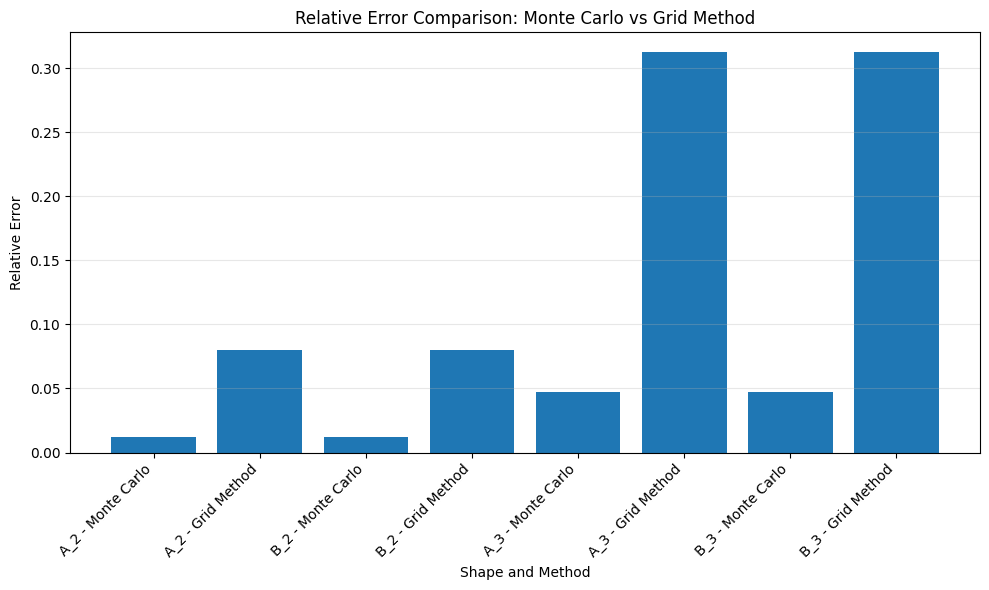

In [77]:
# ============================================================
# Bar chart comparing relative error
# ============================================================

plt.figure(figsize=(10, 6))

x_labels = comparison_table["Shape"] + " - " + comparison_table["Method"]

plt.bar(x_labels, comparison_table["Relative Error"])

plt.title("Relative Error Comparison: Monte Carlo vs Grid Method")
plt.xlabel("Shape and Method")
plt.ylabel("Relative Error")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

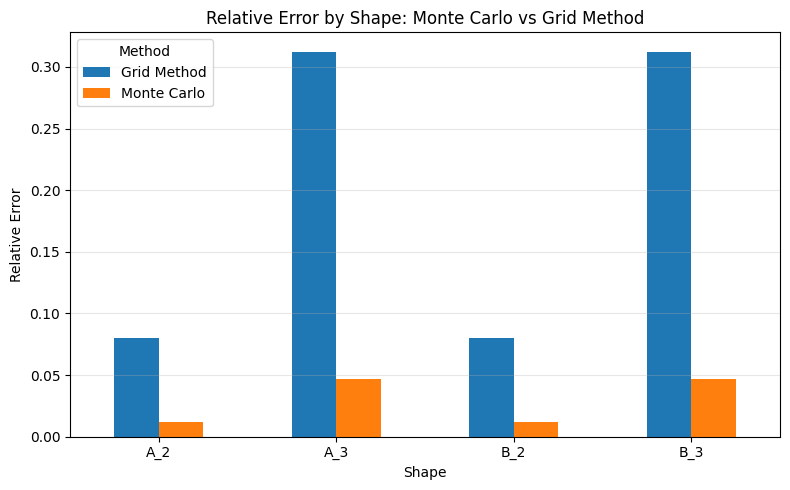

In [78]:
# ============================================================
# Relative error comparison by shape
# ============================================================

pivot_error = comparison_table.pivot(
    index="Shape",
    columns="Method",
    values="Relative Error"
)

pivot_error.plot(kind="bar", figsize=(8, 5))

plt.title("Relative Error by Shape: Monte Carlo vs Grid Method")
plt.xlabel("Shape")
plt.ylabel("Relative Error")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

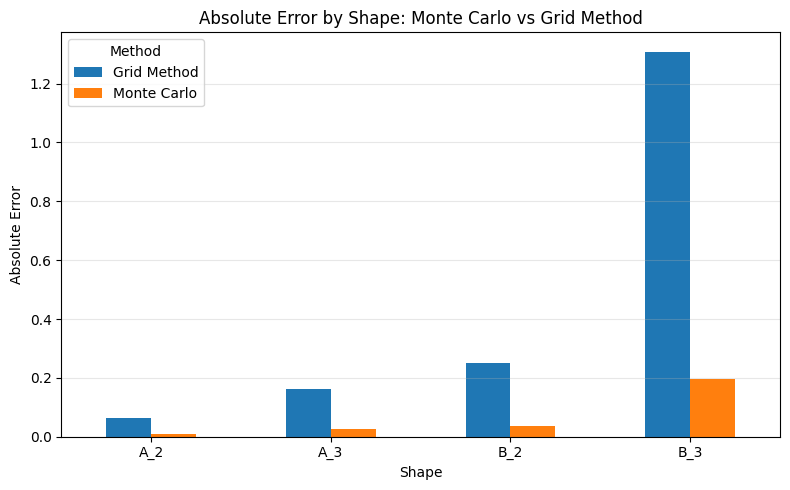

In [79]:
# ============================================================
# Absolute error comparison by shape
# ============================================================

pivot_abs_error = comparison_table.pivot(
    index="Shape",
    columns="Method",
    values="Absolute Error"
)

pivot_abs_error.plot(kind="bar", figsize=(8, 5))

plt.title("Absolute Error by Shape: Monte Carlo vs Grid Method")
plt.xlabel("Shape")
plt.ylabel("Absolute Error")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()